# Programming Language Trends

## Overview

This notebook analyzes historical programming language popularity using publicly available Stack Overflow data.

The analysis demonstrates how to reshape data, handle missing values, smooth time-series data using rolling averages, and visualize long-term technology trends using Python and Pandas.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

Path("figures").mkdir(exist_ok=True)

plt.style.use("ggplot")

In [4]:
languages = pd.read_csv(
    "programming_language_trends.csv",
    names=["DATE", "TAG", "POSTS"],
    header=0
)

languages["DATE"] = pd.to_datetime(languages["DATE"])

languages.head()

,DATE,TAG,POSTS
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,javascript,162
3,2008-08-01,c,85
4,2008-08-01,python,124


In [5]:
languages.info()

languages.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1991 entries, 0 to 1990
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    1991 non-null   datetime64[ns]
 1   TAG     1991 non-null   object        
 2   POSTS   1991 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 46.8+ KB


,DATE,TAG,POSTS
count,1991,1991,1991.000000
unique,NaN,14,NaN
top,NaN,c#,NaN
freq,NaN,145,NaN
mean,2014-08-10 16:46:46.228026112,NaN,5069.401306
min,2008-07-01 00:00:00,NaN,1.000000
25%,2011-09-01 00:00:00,NaN,426.500000
50%,2014-08-01 00:00:00,NaN,2472.000000
75%,2017-08-01 00:00:00,NaN,8163.000000
max,2020-07-01 00:00:00,NaN,34478.000000


## Reshape the Dataset

Each programming language currently exists as a separate row for each date.

To make trend analysis easier, the data is reshaped so each programming language becomes its own column.

In [7]:
reshaped = languages.pivot(
    index="DATE",
    columns="TAG",
    values="POSTS"
)

reshaped.head()

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,8.0,85.0,511.0,164.0,14.0,NaN,222.0,162.0,28.0,161.0,124.0,NaN,73.0,NaN
2008-09-01,28.0,321.0,1649.0,755.0,105.0,NaN,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,NaN
2008-10-01,15.0,303.0,1989.0,811.0,112.0,NaN,1153.0,725.0,127.0,617.0,510.0,NaN,249.0,NaN
2008-11-01,17.0,259.0,1730.0,735.0,141.0,NaN,958.0,579.0,97.0,504.0,452.0,1.0,160.0,NaN


In [8]:
reshaped.fillna(0, inplace=True)

rolling_average = reshaped.rolling(window=6).mean()

rolling_average.head()

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


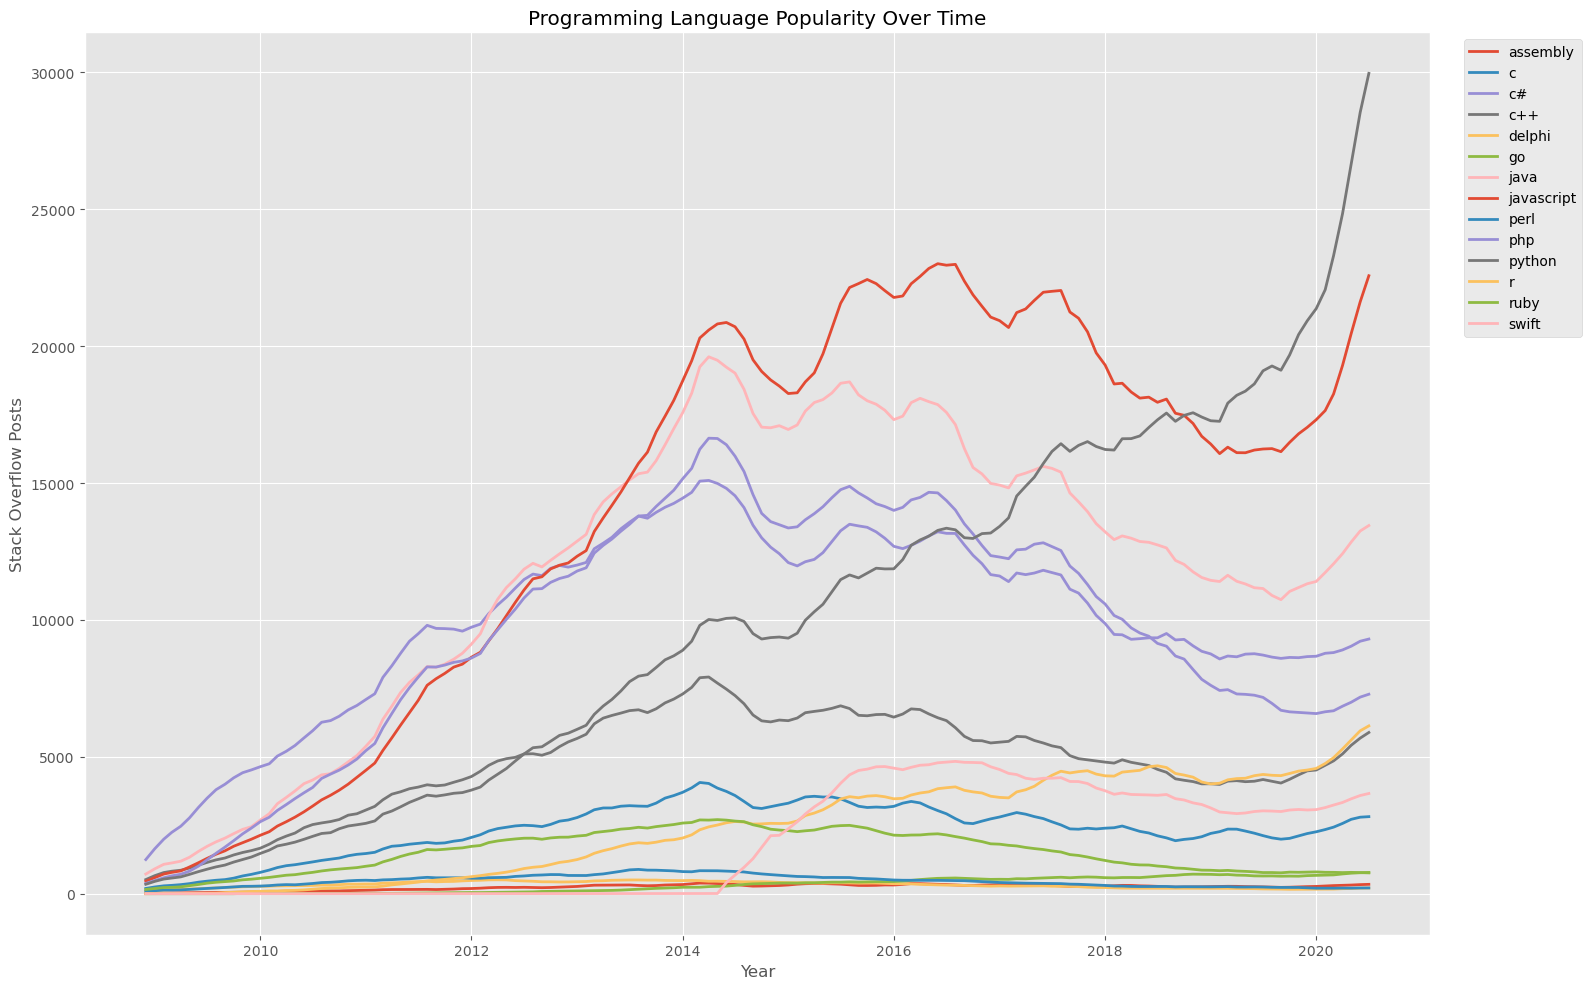

In [9]:
plt.figure(figsize=(16,10))

for language in rolling_average.columns:
    plt.plot(
        rolling_average.index,
        rolling_average[language],
        linewidth=2,
        label=language
    )

plt.title("Programming Language Popularity Over Time")

plt.xlabel("Year")

plt.ylabel("Stack Overflow Posts")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02,1)
)

plt.tight_layout()

plt.savefig(
    "figures/programming_language_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
latest = (
    reshaped
    .iloc[-1]
    .sort_values(ascending=False)
)

latest.head(10)

TAG
python        31261.0
javascript    23802.0
java          12723.0
c#             9145.0
php            7334.0
c++            5756.0
r              5694.0
swift          3607.0
c              2294.0
ruby            775.0
Name: 2020-07-01 00:00:00, dtype: float64

# Conclusions

This notebook demonstrates how Python can be used to analyze technology trends over time using real-world data.

Key techniques demonstrated include:

- Loading and preparing time-series data
- Reshaping data with pivot tables
- Handling missing values
- Applying rolling averages to reduce noise
- Visualizing long-term trends
- Identifying the most popular programming languages based on Stack Overflow activity